# Pell Grant Share and Graduate Earnings in US Four-Year Institutions

**Author:** Dennis O'Higgins

**Dataset:** College Scorecard, most recent institution-level data (U.S. Department of Education), obtained through Data.gov. Catalog entry: https://catalog.data.gov/dataset/college-scorecard-c25e9 and data portal: https://collegescorecard.ed.gov/data

**Analytical question:** Among US institutions that mainly award bachelor's degrees, is the share of undergraduates who receive Pell Grants associated with the median earnings of former students ten years after they first enrolled?

**Notebook sections:** 1. Setup and Data Loading, 2. Data Preparation, 3. Descriptive Statistics, 4. Visual Models, 5. Hypothesis Test, 6. Notebook Summary.

**A note on the term "visual model".** In this project a visual model means a chart that represents a pattern in the data. No machine learning model is trained.

## 1. Setup and Data Loading

The CSV used here (`college_scorecard_subset.csv`) contains all 6,273 institutions from the Department of Education's most recent institution-level file, but only 23 of its 3,308 columns. The full file is 100 MB, so the columns needed for this analysis were selected and no rows or values were altered. The raw file includes text values such as `PrivacySuppressed`, which are handled in Section 2.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

In [2]:
df = pd.read_csv("college_scorecard_subset.csv", low_memory=False)
df.head()

,UNITID,INSTNM,CITY,STABBR,REGION,CONTROL,PREDDEG,HIGHDEG,LOCALE,HBCU,...,COSTT4_A,TUITIONFEE_IN,TUITIONFEE_OUT,C150_4,RET_FT4,PCTPELL,PCTFLOAN,DEBT_MDN,MD_EARN_WNE_P10,UGDS_WOMEN
0,100654,Alabama A & M University,Normal,AL,5,1,3,4,12.0,1.0,...,27153.0,10024.0,18634.0,0.2403,0.6989,0.6298,0.7454,16600,40628.0,0.5779
1,100663,University of Alabama at Birmingham,Birmingham,AL,5,1,3,4,12.0,0.0,...,28145.0,9098.0,22562.0,0.6423,0.8009,0.3402,0.4027,15832,54501.0,0.6320
2,100690,Amridge University,Montgomery,AL,5,2,3,4,12.0,0.0,...,NaN,7590.0,7590.0,1.0000,NaN,0.7655,0.8097,13385,37621.0,0.6556
3,100706,University of Alabama in Huntsville,Huntsville,AL,5,1,3,4,12.0,0.0,...,27392.0,12132.0,26408.0,0.6429,0.8425,0.2464,0.3255,13905,61767.0,0.3905
4,100724,Alabama State University,Montgomery,AL,5,1,3,4,12.0,1.0,...,23586.0,11248.0,19576.0,0.3034,0.6975,0.7134,0.7420,17500,34502.0,0.6347


In [3]:
print("Rows and columns:", df.shape)
print()
df.dtypes

Rows and columns: (6273, 23)



UNITID               int64
INSTNM                 str
CITY                   str
STABBR                 str
REGION               int64
CONTROL              int64
PREDDEG              int64
HIGHDEG              int64
LOCALE             float64
HBCU               float64
UGDS               float64
ADM_RATE           float64
SAT_AVG            float64
COSTT4_A           float64
TUITIONFEE_IN      float64
TUITIONFEE_OUT     float64
C150_4             float64
RET_FT4            float64
PCTPELL            float64
PCTFLOAN           float64
DEBT_MDN               str
MD_EARN_WNE_P10    float64
UGDS_WOMEN         float64
dtype: object

All 23 columns loaded. One column that should be numeric, `DEBT_MDN` (median debt), was read as text, which means it contains non-numeric entries. The next section investigates this before any analysis.

## 2. Data Preparation

Initial data analysis is the stage between data retrieval and the analysis that answers the research question. It checks that the data are of sufficient quality and documents any changes (Lusa et al., 2024). The steps below follow that logic: inspect, correct only what is necessary, and record every decision.

In [4]:
def count_nonnumeric_entries(frame, columns):
    """Count text entries that cannot be converted to numbers in each column.

    Parameters
    ----------
    frame : pandas.DataFrame
        The data to inspect.
    columns : list of str
        Columns that are expected to be numeric.

    Returns
    -------
    pandas.Series
        For each column, the number of non-missing values that fail numeric conversion.
    """
    counts = {}
    for col in columns:
        converted = pd.to_numeric(frame[col], errors="coerce")
        counts[col] = int((converted.isna() & frame[col].notna()).sum())
    return pd.Series(counts, name="non_numeric_entries")


numeric_candidates = ["UGDS", "ADM_RATE", "SAT_AVG", "COSTT4_A", "TUITIONFEE_IN", "TUITIONFEE_OUT",
                      "C150_4", "RET_FT4", "PCTPELL", "PCTFLOAN", "DEBT_MDN", "MD_EARN_WNE_P10", "UGDS_WOMEN"]
count_nonnumeric_entries(df, numeric_candidates)

UGDS                 0
ADM_RATE             0
SAT_AVG              0
COSTT4_A             0
TUITIONFEE_IN        0
TUITIONFEE_OUT       0
C150_4               0
RET_FT4              0
PCTPELL              0
PCTFLOAN             0
DEBT_MDN           885
MD_EARN_WNE_P10      0
UGDS_WOMEN           0
Name: non_numeric_entries, dtype: int64

In [5]:
print("Distinct non-numeric entries in DEBT_MDN:",
      df.loc[pd.to_numeric(df["DEBT_MDN"], errors="coerce").isna() & df["DEBT_MDN"].notna(),
             "DEBT_MDN"].unique())

Distinct non-numeric entries in DEBT_MDN: <StringArray>
['PS']
Length: 1, dtype: str


**Why this cleaning step is necessary.** The only non-numeric entries are the text value `PrivacySuppressed`, which appears 885 times in `DEBT_MDN`. The Department of Education documentation states that federal data elements that do not meet reporting standards are shown as `PrivacySuppressed`. These are not zeros and not errors, so they must be treated as missing rather than converted to a number. Left as text, they would stop `describe()` and correlation from working on that column. The two variables used in the hypothesis test, Pell share and earnings, are already numeric, so they are not affected by suppression, although earnings do contain ordinary blank (missing) values, which are examined below.

In [6]:
CONTROL_LABELS = {1: "Public", 2: "Private nonprofit", 3: "Private for-profit"}


def convert_to_numeric(frame, columns):
    """Convert columns to numbers, turning suppressed or text entries into missing values.

    Parameters
    ----------
    frame : pandas.DataFrame
        The data to convert. The original is not modified.
    columns : list of str
        Columns to convert.

    Returns
    -------
    pandas.DataFrame
        A copy in which each listed column is numeric and unusable entries are NaN.
    """
    out = frame.copy()
    for col in columns:
        out[col] = pd.to_numeric(out[col], errors="coerce")
    return out


def prepare_analysis_sample(frame, predominant_degree=3):
    """Restrict to bachelor's-granting institutions and label the control variable.

    Parameters
    ----------
    frame : pandas.DataFrame
        Numeric-converted College Scorecard data.
    predominant_degree : int, default 3
        Value of PREDDEG to keep. In this file 3 identifies institutions whose predominant
        award is the bachelor's degree.

    Returns
    -------
    pandas.DataFrame
        Selected institutions with a readable `control_type` column and renamed key variables.
    """
    out = frame.loc[frame["PREDDEG"] == predominant_degree].copy()
    out["control_type"] = out["CONTROL"].map(CONTROL_LABELS)
    out = out.rename(columns={"PCTPELL": "pell_share", "MD_EARN_WNE_P10": "median_earnings_10yr",
                              "C150_4": "completion_rate", "COSTT4_A": "cost_of_attendance",
                              "ADM_RATE": "admission_rate", "UGDS": "undergrad_enrollment"})
    return out


def report_missing(frame, columns):
    """Return the count and percentage of missing values for the given columns.

    Parameters
    ----------
    frame : pandas.DataFrame
        The data to inspect.
    columns : list of str
        Columns to summarise.

    Returns
    -------
    pandas.DataFrame
        One row per column with `missing` and `percent_missing`.
    """
    miss = frame[columns].isna().sum()
    return pd.DataFrame({"missing": miss, "percent_missing": (miss / len(frame) * 100).round(1)})


df_num = convert_to_numeric(df, numeric_candidates)
bach = prepare_analysis_sample(df_num)
print("All institutions:", len(df_num))
print("Bachelor's-granting institutions kept:", len(bach))
print()
key_cols = ["pell_share", "median_earnings_10yr", "completion_rate", "cost_of_attendance",
            "admission_rate", "undergrad_enrollment"]
report_missing(bach, key_cols)

All institutions: 6273
Bachelor's-granting institutions kept: 1947



,missing,percent_missing
pell_share,23,1.2
median_earnings_10yr,155,8.0
completion_rate,150,7.7
cost_of_attendance,185,9.5
admission_rate,362,18.6
undergrad_enrollment,9,0.5


**Why restrict to bachelor's-granting institutions.** The file also contains certificate-granting and two-year institutions, whose students, costs and earnings profiles differ greatly from four-year institutions. Mixing them would make a comparison of Pell share and earnings hard to interpret. Restricting to the 1,947 institutions whose predominant award is the bachelor's degree makes the sample comparable. This is an analytical decision, and it is recorded here because it limits who the conclusions describe.

**Why missing values are not imputed.** Earnings are missing for about eight percent of the selected institutions, and this missingness is probably not random (small or new institutions are more likely to lack data). Filling the gaps with averages would invent values, so the hypothesis test uses only institutions that have both variables, and the number used is reported.

In [7]:
analysis_df = bach.dropna(subset=["pell_share", "median_earnings_10yr"]).copy()
print("Institutions with both Pell share and earnings:", len(analysis_df))
print("Dropped because one of the two was missing:", len(bach) - len(analysis_df))

Institutions with both Pell share and earnings: 1787
Dropped because one of the two was missing: 160


In [8]:
def flag_shared_earnings(frame, value_col="median_earnings_10yr"):
    """Flag institutions whose earnings value is identical to that of at least one other institution.

    Parameters
    ----------
    frame : pandas.DataFrame
        Data containing the earnings column.
    value_col : str
        Name of the earnings column.

    Returns
    -------
    pandas.Series
        Boolean series that is True where the earnings value is shared with another row.
    """
    return frame.duplicated(subset=[value_col], keep=False)


analysis_df["shares_earnings_value"] = flag_shared_earnings(analysis_df)
shared_summary = (analysis_df.groupby("control_type")["shares_earnings_value"]
                  .agg(shared="sum", total="count"))
shared_summary["percent_shared"] = (shared_summary["shared"] / shared_summary["total"] * 100).round(1)
shared_summary

,shared,total,percent_shared
control_type,,,
Private for-profit,82,127,64.6
Private nonprofit,99,1074,9.2
Public,94,586,16.0


In [9]:
for value in [63435, 40092, 92405]:
    names = analysis_df.loc[analysis_df["median_earnings_10yr"] == value, "INSTNM"]
    print(f"Earnings value {value:,}: {len(names)} institutions, for example:")
    print("   ", "; ".join(names.head(3)))

Earnings value 63,435: 21 institutions, for example:
    Pennsylvania State University-Penn State Erie-Behrend College; Pennsylvania State University-Penn State New Kensington; Pennsylvania State University-Penn State Shenango
Earnings value 40,092: 17 institutions, for example:
    Strayer University-District of Columbia; Strayer University-Virginia; Strayer University-Maryland
Earnings value 92,405: 15 institutions, for example:
    Chamberlain University-Illinois; Chamberlain University-Ohio; Chamberlain University-Arizona


**A data-quality finding.** Many institutions report exactly the same earnings value as other institutions. The examples above show that these are campuses of one university system or chain (for example several Penn State campuses share one value, as do Strayer University and Chamberlain University campuses in different states). The most likely explanation is that earnings are reported for the parent institution and repeated for each campus, although the data file does not state this directly. The consequence is that institutions are not fully independent observations, which matters for the hypothesis test. The test is therefore also repeated in Section 5 with one institution kept for each shared earnings value and control type, as a sensitivity check. Nothing is deleted from the main sample, because each campus has its own Pell share.

## 3. Descriptive Statistics

In [10]:
analysis_df[["pell_share", "median_earnings_10yr", "completion_rate", "cost_of_attendance",
             "admission_rate", "undergrad_enrollment"]].describe().round(3)

,pell_share,median_earnings_10yr,completion_rate,cost_of_attendance,admission_rate,undergrad_enrollment
count,1787.000,1787.000,1685.000,1672.000,1501.000,1787.000
mean,0.367,56077.513,0.548,42020.371,0.722,4863.860
std,0.172,16916.526,0.199,19547.719,0.224,9570.977
min,0.000,17360.000,0.000,9057.000,0.026,1.000
25%,0.241,45388.500,0.421,25590.500,0.615,770.500
50%,0.339,53800.000,0.550,38101.500,0.771,1762.000
75%,0.457,63435.000,0.682,54794.000,0.892,4760.000
max,0.993,143372.000,1.000,93512.000,1.000,163164.000


The median institution has a Pell share of about 0.34 and median earnings of about 53,800 US dollars ten years after entry. Earnings range from about 17,000 to about 143,000 US dollars, and the mean (56,078 dollars) sits above the median, which hints at a right-skewed distribution. Enrollment is extremely skewed: the median institution has about 1,760 undergraduates, but the largest has over 160,000.

In [11]:
counts = (analysis_df["control_type"].value_counts()
          .rename_axis("control_type").reset_index(name="institutions"))
counts["percent"] = (counts["institutions"] / counts["institutions"].sum() * 100).round(1)
counts

,control_type,institutions,percent
0,Private nonprofit,1074,60.1
1,Public,586,32.8
2,Private for-profit,127,7.1


In [12]:
def summarise_by_group(frame, group_col, value_col):
    """Summarise a numeric variable within each category of a grouping variable.

    Parameters
    ----------
    frame : pandas.DataFrame
        The data to summarise.
    group_col : str
        Categorical column that defines the groups.
    value_col : str
        Numeric column to summarise.

    Returns
    -------
    pandas.DataFrame
        Count, mean, median, standard deviation and interquartile range for each group.
    """
    grouped = frame.groupby(group_col)[value_col]
    out = grouped.agg(["count", "mean", "median", "std"])
    out["iqr"] = grouped.quantile(0.75) - grouped.quantile(0.25)
    return out.round(3)


summarise_by_group(analysis_df, "control_type", "median_earnings_10yr")

,count,mean,median,std,iqr
control_type,,,,,
Private for-profit,127,50965.378,40092.0,23307.023,25561.00
Private nonprofit,1074,56619.384,54055.5,17816.986,18023.75
Public,586,56192.311,54664.5,12968.840,16117.75


In [13]:
summarise_by_group(analysis_df, "control_type", "pell_share")

,count,mean,median,std,iqr
control_type,,,,,
Private for-profit,127,0.526,0.537,0.190,0.235
Private nonprofit,1074,0.353,0.323,0.174,0.216
Public,586,0.356,0.339,0.145,0.168


In [14]:
print("Skewness of median earnings:", round(analysis_df["median_earnings_10yr"].skew(), 3))
print("Skewness of Pell share:     ", round(analysis_df["pell_share"].skew(), 3))
print("Skewness of enrollment:     ", round(analysis_df["undergrad_enrollment"].skew(), 3))

Skewness of median earnings: 1.135
Skewness of Pell share:      0.871
Skewness of enrollment:      6.888


**What these statistics reveal.** Private nonprofit institutions make up the majority of the sample (60 percent), followed by public institutions (33 percent), and for-profit institutions are the smallest group (7 percent). Earnings are right-skewed (skewness about 1.1) and Pell share is moderately right-skewed (0.87), so medians describe a typical institution better than means. Public and private nonprofit institutions have almost the same median earnings (about 54,000 dollars) and Pell share (about 0.33), whereas for-profit institutions have a much lower median earnings (40,092 dollars) and a much higher median Pell share (0.54). The type of institution will therefore need to be kept in mind when interpreting any overall relationship.

## 4. Visual Models

Four visual models are built. Each is designed to show a different aspect of the question, and Section 4.5 compares them.

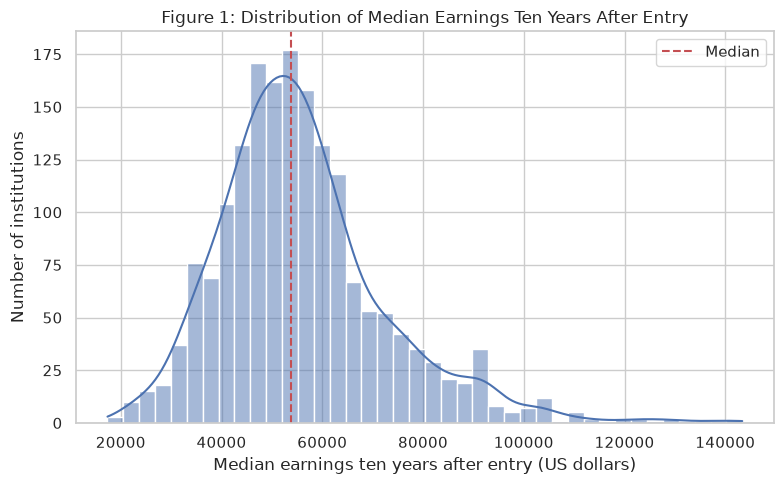

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(analysis_df["median_earnings_10yr"], bins=40, kde=True, color="#4C72B0", ax=ax)
ax.axvline(analysis_df["median_earnings_10yr"].median(), color="#C44E52", linestyle="--", label="Median")
ax.set_title("Figure 1: Distribution of Median Earnings Ten Years After Entry")
ax.set_xlabel("Median earnings ten years after entry (US dollars)")
ax.set_ylabel("Number of institutions")
ax.legend()
fig.tight_layout()
fig.savefig("figures/figure_1_earnings_distribution.png", dpi=150)
plt.show()

**Figure 1 interpretation.** Half of the institutions have earnings between about 45,000 and 63,000 US dollars, with a long tail of 38 institutions above 100,000 dollars and a maximum of about 143,000 dollars. The distribution is right-skewed, so a method that assumes normally distributed data would be a poor fit for these values, which supports the use of a rank-based correlation in Section 5.

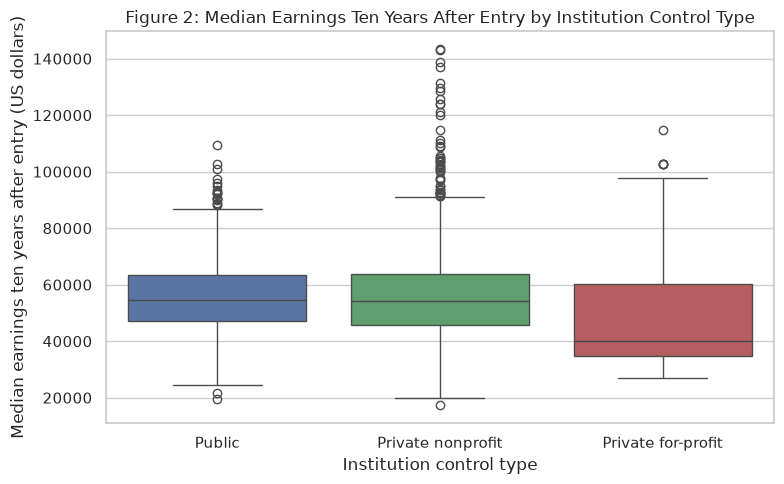

In [16]:
order = ["Public", "Private nonprofit", "Private for-profit"]
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=analysis_df, x="control_type", y="median_earnings_10yr", order=order,
            palette=["#4C72B0", "#55A868", "#C44E52"], hue="control_type", legend=False, ax=ax)
ax.set_title("Figure 2: Median Earnings Ten Years After Entry by Institution Control Type")
ax.set_xlabel("Institution control type")
ax.set_ylabel("Median earnings ten years after entry (US dollars)")
fig.tight_layout()
fig.savefig("figures/figure_2_earnings_by_control.png", dpi=150)
plt.show()

**Figure 2 interpretation.** Public and private nonprofit institutions have almost identical median earnings (about 54,000 dollars), but private nonprofit institutions show more spread and the most high outliers (46 points beyond the whiskers, against 18 for public institutions). For-profit institutions have a visibly lower median (about 40,000 dollars) and a wide spread. Control type is therefore related to earnings and could confuse an overall relationship between Pell share and earnings.

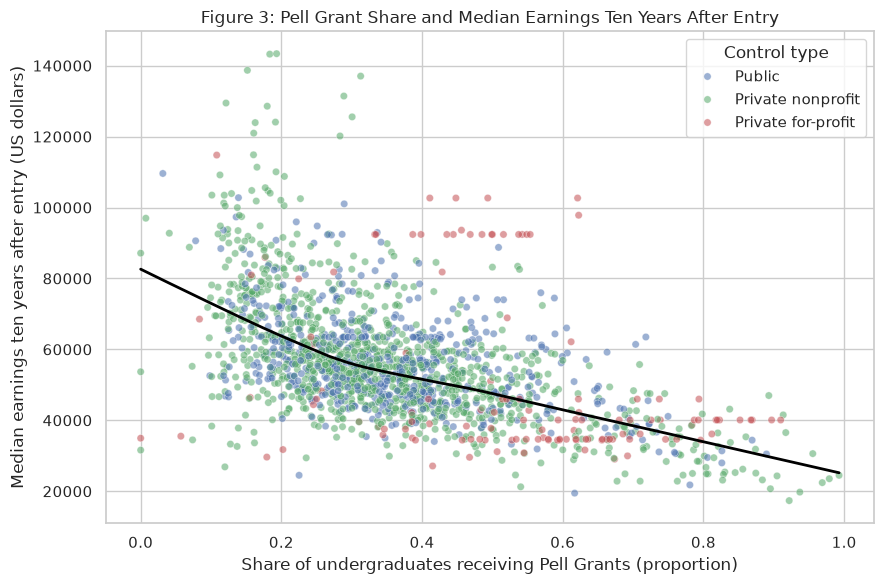

In [17]:
colors = {"Public": "#4C72B0", "Private nonprofit": "#55A868", "Private for-profit": "#C44E52"}
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=analysis_df, x="pell_share", y="median_earnings_10yr", hue="control_type",
                hue_order=order, palette=colors, alpha=0.55, s=28, ax=ax)
sns.regplot(data=analysis_df, x="pell_share", y="median_earnings_10yr", scatter=False, lowess=True,
            line_kws={"color": "black", "linewidth": 2}, ax=ax)
ax.set_title("Figure 3: Pell Grant Share and Median Earnings Ten Years After Entry")
ax.set_xlabel("Share of undergraduates receiving Pell Grants (proportion)")
ax.set_ylabel("Median earnings ten years after entry (US dollars)")
ax.legend(title="Control type")
fig.tight_layout()
fig.savefig("figures/figure_3_pell_vs_earnings.png", dpi=150)
plt.show()

In [18]:
pell_bins = pd.cut(analysis_df["pell_share"], [0, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0], include_lowest=True)
(analysis_df.groupby(pell_bins, observed=True)["median_earnings_10yr"]
 .agg(institutions="count", median_earnings="median").round(0))

,institutions,median_earnings
pell_share,,
"(-0.001, 0.2]",276,70012.0
"(0.2, 0.3]",432,57358.0
"(0.3, 0.4]",449,53623.0
"(0.4, 0.5]",290,49740.0
"(0.5, 0.6]",160,46494.0
"(0.6, 0.8]",137,37837.0
"(0.8, 1.0]",43,30512.0


**Figure 3 interpretation.** Institutions with a higher share of Pell Grant recipients tend to have lower earnings, and the smoothed curve falls from about 83,000 dollars at a Pell share near zero to about 25,000 dollars near 1.0. The fall is steepest at low Pell shares and more gradual afterwards, so the relationship is consistently decreasing but not a straight line. The points are scattered widely around the curve, so Pell share alone leaves much of the variation in earnings unexplained. For-profit institutions (red) sit mostly at high Pell shares, and the horizontal rows of identical red points are campuses of the same chain that share one earnings value, as found in Section 2.

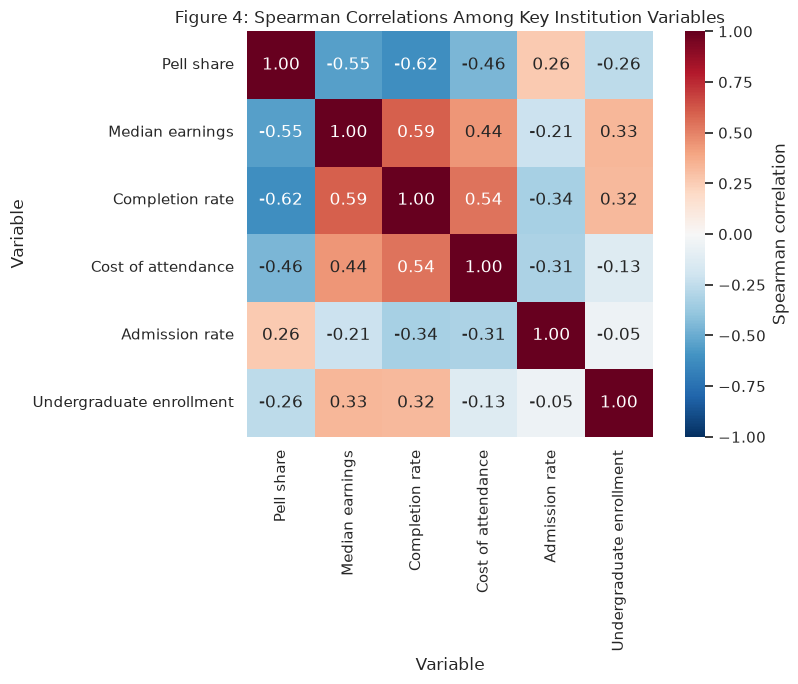

In [19]:
heat_cols = ["pell_share", "median_earnings_10yr", "completion_rate", "cost_of_attendance",
             "admission_rate", "undergrad_enrollment"]
heat_labels = ["Pell share", "Median earnings", "Completion rate", "Cost of attendance",
               "Admission rate", "Undergraduate enrollment"]
corr = analysis_df[heat_cols].corr(method="spearman")
corr.index = heat_labels
corr.columns = heat_labels
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, square=True, ax=ax,
            cbar_kws={"label": "Spearman correlation"})
ax.set_title("Figure 4: Spearman Correlations Among Key Institution Variables")
ax.set_xlabel("Variable")
ax.set_ylabel("Variable")
fig.tight_layout()
fig.savefig("figures/figure_4_correlation_heatmap.png", dpi=150)
plt.show()

**Figure 4 interpretation.** Pell share has a moderate negative rank correlation with median earnings (-0.55) and with completion rate (-0.62) and a somewhat smaller negative correlation with cost of attendance (-0.46), while completion rate and earnings are moderately positively related (0.59). Admission rate shows only weak correlations with the other variables (from -0.34 to 0.26). Each cell uses all institutions that have values for that pair. Because Pell share, completion, cost and earnings are all related to one another, Pell share overlaps with other institutional characteristics, so its link with earnings cannot be interpreted in isolation.

### 4.5 Comparison of the Visual Models

In [20]:
rho_all = stats.spearmanr(analysis_df["pell_share"], analysis_df["median_earnings_10yr"])[0]
med = analysis_df.groupby("control_type")["median_earnings_10yr"].median()
comparison = pd.DataFrame({
    "Visual model": ["Figure 1 histogram", "Figure 2 boxplot", "Figure 3 scatterplot", "Figure 4 heatmap"],
    "Variables shown": ["Earnings", "Earnings by control type", "Pell share and earnings", "Six variables, pairwise"],
    "Key quantity it exposes": [
        f"Skewness {analysis_df['median_earnings_10yr'].skew():.2f}",
        f"Group medians {med['Public']:,.0f} / {med['Private nonprofit']:,.0f} / {med['Private for-profit']:,.0f}",
        f"Spearman rho {rho_all:.2f}",
        f"Pell and earnings rho {corr.loc['Pell share', 'Median earnings']:.2f}"],
    "Directly shows Pell-earnings link": ["No", "No", "Yes, with shape and spread", "Yes, as one number"],
})
comparison

,Visual model,Variables shown,Key quantity it exposes,Directly shows Pell-earnings link
0,Figure 1 histogram,Earnings,Skewness 1.13,No
1,Figure 2 boxplot,Earnings by control type,"Group medians 54,664 / 54,056 / 40,092",No
2,Figure 3 scatterplot,Pell share and earnings,Spearman rho -0.55,"Yes, with shape and spread"
3,Figure 4 heatmap,"Six variables, pairwise",Pell and earnings rho -0.55,"Yes, as one number"


**Comparison and trade-offs.** Each visual model answers a different question. The histogram (Figure 1) describes the outcome on its own and shows the skew, which guided the choice of a rank-based test, but it says nothing about Pell share. The boxplot (Figure 2) compares groups and reveals the outliers and the lower for-profit median, but it hides the continuous relationship. The heatmap (Figure 4) summarises many relationships compactly and exposes overlap among variables, but it reduces each pair to one number and cannot show curvature or outliers. The scatterplot with a smoothed curve (Figure 3) shows the direction, shape, spread and group structure of exactly the two variables in the analytical question, at the cost of more visual detail. **Figure 3 best supports the analytical question**, and the other three explain why it is analysed with a rank correlation and why control type and overlap with other variables need to be mentioned as caveats.

## 5. Hypothesis Test

The research question asks about the association between two continuous variables, and Figure 1 showed that earnings are skewed with outliers. Figure 3 showed a monotonic (consistently decreasing) but not perfectly linear relationship. A Spearman rank correlation test is therefore appropriate.

**Null hypothesis (H0):** There is no monotonic association between the share of undergraduates receiving Pell Grants and median earnings ten years after entry among bachelor's-granting institutions (the population Spearman correlation is zero).

**Alternative hypothesis (H1):** There is a monotonic association between the two variables (the population Spearman correlation is not zero).

**Significance level:** 0.05, two-sided.

In [21]:
def spearman_test(frame, x_col, y_col, n_boot=2000, seed=RANDOM_SEED):
    """Run a two-sided Spearman rank correlation test with a bootstrap confidence interval.

    Parameters
    ----------
    frame : pandas.DataFrame
        Data containing both columns with no missing values.
    x_col, y_col : str
        Names of the two numeric columns.
    n_boot : int, default 2000
        Number of bootstrap resamples for the confidence interval.
    seed : int
        Seed for the random number generator so results are reproducible.

    Returns
    -------
    dict
        Sample size, Spearman rho, p-value, and a 95 percent percentile bootstrap interval.
    """
    x = frame[x_col].to_numpy()
    y = frame[y_col].to_numpy()
    result = stats.spearmanr(x, y)
    gen = np.random.default_rng(seed)
    boots = []
    for _ in range(n_boot):
        idx = gen.integers(0, len(x), len(x))
        boots.append(stats.spearmanr(x[idx], y[idx])[0])
    low, high = np.percentile(boots, [2.5, 97.5])
    return {"n": len(x), "rho": result.statistic, "p_value": result.pvalue,
            "ci_low": low, "ci_high": high}


test = spearman_test(analysis_df, "pell_share", "median_earnings_10yr")
print(f"Number of institutions (n):      {test['n']}")
print(f"Spearman correlation (rho):      {test['rho']:.3f}")
print(f"Test p-value:                    {test['p_value']:.3e}")
print(f"95% bootstrap interval for rho:  [{test['ci_low']:.3f}, {test['ci_high']:.3f}]")
print("Decision at alpha = 0.05:        ", "reject H0" if test["p_value"] < 0.05 else "fail to reject H0")

Number of institutions (n):      1787
Spearman correlation (rho):      -0.550
Test p-value:                    1.330e-141
95% bootstrap interval for rho:  [-0.586, -0.510]
Decision at alpha = 0.05:         reject H0


In [22]:
# Sensitivity check: the same test within each control type
rows = []
for name in order:
    sub = analysis_df[analysis_df["control_type"] == name]
    r = stats.spearmanr(sub["pell_share"], sub["median_earnings_10yr"])
    rows.append({"control_type": name, "n": len(sub), "rho": round(r.statistic, 3), "p_value": r.pvalue})
pd.DataFrame(rows)

,control_type,n,rho,p_value
0,Public,586,-0.409,4.436565e-25
1,Private nonprofit,1074,-0.613,1.318802e-111
2,Private for-profit,127,-0.280,1.451359e-03


In [23]:
# Sensitivity check: keep one institution per shared earnings value within each control type
# (campuses of one system report the same earnings value, see Section 2)
distinct_df = analysis_df.drop_duplicates(subset=["control_type", "median_earnings_10yr"], keep="first")
r_distinct = stats.spearmanr(distinct_df["pell_share"], distinct_df["median_earnings_10yr"])
print(f"Institutions kept after removing repeated earnings values: {len(distinct_df)} of {len(analysis_df)}")
print(f"Spearman rho = {r_distinct.statistic:.3f}, p-value = {r_distinct.pvalue:.3e}")

Institutions kept after removing repeated earnings values: 1612 of 1787
Spearman rho = -0.561, p-value = 3.641e-134


The full interpretation of this test, including its assumptions, is given in the written report.

## 6. Notebook Summary

I explored the relationship between the share of Pell Grant recipients and median earnings across 1,787 US institutions that mainly award bachelor's degrees. The main finding is a moderate negative association (Spearman rho of -0.55): institutions with higher Pell shares tend to have lower earnings ten years after entry, and the test rejects the hypothesis of no association. A surprising result was that campuses of the same system report identical earnings values, so the observations are not fully independent, although the association remains almost unchanged when the test is repeated without the repeated values. Challenges included the `PrivacySuppressed` text entries in the debt column, the skewed earnings that ruled out a method based on normality, and the overlap between Pell share and other institutional characteristics. The result describes institutions, not individual students, and it does not show that Pell share causes lower earnings.